# TRL Debug & Training Harness — `pointmaze-large-navigate-v0`

This notebook runs the Transitive RL pipeline on a sanity-check task (no oracle-distillation required). It is organized as:

1. **Environment setup** — GPU runtime, installs, path config
2. **Repo upload** — mount the zipped repo into the Colab workspace
3. **Sanity checks** — confirm JAX sees the GPU, imports resolve, TRL agent initializes
4. **Smoke test** — 500 steps with tiny batch; assert the pipeline doesn't crash and losses behave
5. **Full training run** — 1M steps, eval every 100K, checkpoint to Drive
6. **Plots & rollouts** — learning curves, $Q$-value histograms, evaluation video

**Before you run anything:** Runtime → Change runtime type → **T4 GPU**. If you don't do this, everything will work, but training will be ~10× slower and you will be sad.

## 1. Environment setup

In [ ]:
# Confirm we have a GPU before installing anything heavy.
!nvidia-smi

Wed Apr 29 02:57:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P0             34W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install repo requirements. Pinned to minimize Colab-specific breakage.
# JAX CUDA wheels need to match the driver; Colab's current default works with jax[cuda12].
# If JAX-CUDA detection fails later, the most common fix is reinstalling the matching wheel.
!pip install -q \
    "jax[cuda12]>=0.4.26" \
    "flax>=0.8.4" \
    "distrax>=0.1.5" \
    ml_collections \
    matplotlib \
    moviepy \
    wandb \
    ogbench \
    imageio \
    tqdm

In [ ]:
# Mount Drive to persist dataset downloads and checkpoints across sessions.
# OGBench datasets are ~1GB and redownloading every session is painful.
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['MUJOCO_GL'] = 'egl'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Upload & unpack the repo

Upload your `Transitive_Reinforcement_Learning_COS435.zip` to this Colab session, then run the next cell. The repo's `impls/` directory becomes the working directory for everything that follows.

For everyone except Veronica, make sure to add a shortcut to the shared folder in your drive and paste your filepath below in your codeblock (NOTE: you don't comment out other people's filepaths when you run your own version)

In [ ]:
# Veronica's filepath
cd /content/drive/MyDrive/cos435-final-project/test-runs/Transitive_Reinforcement_Learning_COS435/ogbench-master/impls

[Errno 2] No such file or directory: '/content/drive/MyDrive/cos435-final-project/test-runs/Transitive_Reinforcement_Learning_COS435/ogbench-master/impls'
/content


In [ ]:
# Luke's filepath
%cd "/content/drive/MyDrive/Year 3/Sem 2/COS435/cos435-final-project/test-runs/Transitive_Reinforcement_Learning_COS435/ogbench-master/impls"


/content/drive/.shortcut-targets-by-id/1be05oOTeH9PxR215dunxExGyuFWIxWKI/cos435-final-project/test-runs/Transitive_Reinforcement_Learning_COS435/ogbench-master/impls


In [ ]:
# Tate's filepath

In [ ]:
# Cheryl's filepath

In [ ]:
# Maya's filepath

## 3. Sanity checks

Before burning GPU time, confirm the obvious things work: JAX sees the GPU, the TRL agent imports, and the dataset loads.

In [ ]:
# Check: JAX sees the GPU
import jax
print('JAX version:', jax.__version__)
print('Devices:', jax.devices())
assert any('gpu' in str(d).lower() or 'cuda' in str(d).lower() for d in jax.devices()), (
    'No GPU found. Go to Runtime -> Change runtime type -> T4 GPU.'
)

JAX version: 0.7.2
Devices: [CudaDevice(id=0)]


In [ ]:
# Check: TRL agent imports cleanly
from agents import agents
from agents.trl import get_config
from utils.datasets import Dataset, TRLDataset
from utils.env_utils import make_env_and_datasets

config = get_config()
config["discount"] = 0.99 # for short horizon tasks!
config["alpha"] = 10.0
config["distance_weight_lambda"] = 0.7
print(f'Agent: {config["agent_name"]}')
print(f'Discount: {config["discount"]}')
print(f'Expectile: {config["expectile"]}')
print(f'Alpha: {config["alpha"]}')
print(f'Lambda: {config["distance_weight_lambda"]}')
print(f'Policy extraction: {config["policy_extraction"]}')
'''assert config['policy_extraction'] == 'ddpgbc', (
    'Policy extraction must be ddpgbc for pointmaze; rejection is not implemented.'
)''';

/content/drive/.shortcut-targets-by-id/1be05oOTeH9PxR215dunxExGyuFWIxWKI/cos435-final-project/test-runs/Transitive_Reinforcement_Learning_COS435/ogbench-master/impls/agents/trl.py:33: SyntaxWarning: invalid escape sequence '\e'
  \ell_{\kappa}^{2}(x) = |\kappa - 1_{x < 0}| * x^2
/content/drive/.shortcut-targets-by-id/1be05oOTeH9PxR215dunxExGyuFWIxWKI/cos435-final-project/test-runs/Transitive_Reinforcement_Learning_COS435/ogbench-master/impls/agents/trl.py:124: SyntaxWarning: invalid escape sequence '\l'
  w(s_i, s_j) = (1 + \log_{\gamma} Q(s_i, a_i, s_j))^{-\lambda}
/content/drive/.shortcut-targets-by-id/1be05oOTeH9PxR215dunxExGyuFWIxWKI/cos435-final-project/test-runs/Transitive_Reinforcement_Learning_COS435/ogbench-master/impls/agents/trl.py:156: SyntaxWarning: invalid escape sequence '\s'
  L^{TRL}(Q) = E_{\tau \sim D}[


Agent: trl
Discount: 0.99
Expectile: 0.7
Alpha: 10.0
Lambda: 0.7
Policy extraction: rejection


In [ ]:
# Check: load the env + dataset. First run downloads ~1GB to Drive.
ENV_NAME = 'pointmaze-large-navigate-v0'
print(f'Loading {ENV_NAME} (first run will download the dataset)...')
env, train_dataset, val_dataset = make_env_and_datasets(ENV_NAME, frame_stack=config['frame_stack'])
print(f'Observation shape: {train_dataset["observations"].shape}')
print(f'Action shape: {train_dataset["actions"].shape}')
print(f'Terminals sum (number of trajectories): {train_dataset["terminals"].sum()}')

# Wrap in TRLDataset
train_dataset_trl = TRLDataset(Dataset.create(**train_dataset), config)
if val_dataset is not None:
    val_dataset_trl = TRLDataset(Dataset.create(**val_dataset), config)
else:
    val_dataset_trl = None
print(f'Trajectories: {len(train_dataset_trl.lengths)}')
print(f'Length stats: min={train_dataset_trl.lengths.min()}, '
      f'median={int(np.median(train_dataset_trl.lengths)) if False else "..."} '
      f'max={train_dataset_trl.lengths.max()}')

Loading pointmaze-large-navigate-v0 (first run will download the dataset)...
Observation shape: (1001000, 2)
Action shape: (1001000, 2)
Terminals sum (number of trajectories): 2000.0
Trajectories: 2000
Length stats: min=1, median=... max=1000


In [ ]:
# Check: a batch has the expected TRL keys
import numpy as np
batch = train_dataset_trl.sample(8)
expected_keys = {'s_i', 'a_i', 's_j', 'a_j', 's_k', 'a_k', 'leg1_len', 'leg2_len', 'observations', 'actions'}
missing = expected_keys - set(batch.keys())
assert not missing, f'Missing keys in batch: {missing}'
print('Batch keys look correct.')
print(f'  s_i shape: {batch["s_i"].shape}')
print(f'  leg1_len range: [{batch["leg1_len"].min()}, {batch["leg1_len"].max()}]')
print(f'  leg2_len range: [{batch["leg2_len"].min()}, {batch["leg2_len"].max()}]')

# Sanity invariant: i < j strictly
assert (batch['leg1_len'] + batch['leg2_len'] > 0).all(), (
    'Found a sample where i == j; this breaks the transitive target.'
)

Batch keys look correct.
  s_i shape: (8, 2)
  leg1_len range: [1, 162]
  leg2_len range: [2, 67]


In [ ]:
# Check: TRL agent initializes
import random
SEED = 0
random.seed(SEED); np.random.seed(SEED)

example_batch = train_dataset_trl.sample(1)
agent_class = agents[config['agent_name']]
agent = agent_class.create(
    SEED,
    example_batch['observations'],
    example_batch['actions'],
    config,
)
print('TRL agent created.')

TRL agent created.


## 4. Smoke test

500 steps, batch 64. This should take well under 2 minutes. What we're checking for:

- **No NaN/inf** in critic or actor loss.
- **Critic loss decreases** (or at least stays bounded).
- **`pred_mean` stays in [0, 1]**, since the critic outputs sigmoid-squashed $Q$ values interpreted as $\gamma^{\text{distance}}$.
- **`q_vals` not collapsed**: actor's critic evaluations shouldn't all be identical.

If any of these fail, the full run will fail too — stop and debug before wasting an hour.

In [ ]:
from collections import defaultdict
import time

SMOKE_STEPS = 500
SMOKE_BATCH = 64
smoke_log = defaultdict(list)

t0 = time.time()
for step in range(1, SMOKE_STEPS + 1):
    batch = train_dataset_trl.sample(SMOKE_BATCH)
    agent, info = agent.update(batch)
    for k, v in info.items():
        smoke_log[k].append(float(v))
    if step % 50 == 0:
        print(f'step {step:4d} | '
              f'critic_loss {info["critic/critic_loss"]:.4f} | '
              f'pred_mean {info["critic/pred_mean"]:.3f} | '
              f'target_mean {info["critic/target_mean"]:.3f} | '
              f'q_mean {info["actor/q_mean"]:.3f}'
              )
print(f'Smoke test: {SMOKE_STEPS} steps in {time.time() - t0:.1f}s')

step   50 | critic_loss 0.0001 | pred_mean -4.990 | target_mean 0.000 | q_mean -4.990
step  100 | critic_loss 0.0014 | pred_mean -5.588 | target_mean 0.031 | q_mean -5.588
step  150 | critic_loss 0.0000 | pred_mean -5.814 | target_mean 0.000 | q_mean -5.814
step  200 | critic_loss 0.0001 | pred_mean -4.800 | target_mean 0.001 | q_mean -4.800
step  250 | critic_loss 0.0007 | pred_mean -6.179 | target_mean 0.016 | q_mean -6.179
step  300 | critic_loss 0.0007 | pred_mean -5.522 | target_mean 0.016 | q_mean -5.522
step  350 | critic_loss 0.0020 | pred_mean -6.459 | target_mean 0.048 | q_mean -6.459
step  400 | critic_loss 0.0001 | pred_mean -6.851 | target_mean 0.002 | q_mean -6.851
step  450 | critic_loss 0.0001 | pred_mean -6.984 | target_mean 0.002 | q_mean -6.984
step  500 | critic_loss 0.0007 | pred_mean -7.935 | target_mean 0.016 | q_mean -7.935
Smoke test: 500 steps in 14.9s


In [ ]:
# Smoke test assertions
import math

def _finite(x):
    return math.isfinite(x)

last_critic = smoke_log['critic/critic_loss'][-1]
first_critic = smoke_log['critic/critic_loss'][0]
last_pred_mean = smoke_log['critic/pred_mean'][-1]
first_pred_mean = smoke_log['critic/pred_mean'][0]

checks = {
    'critic loss is finite':          _finite(last_critic),
    'actor loss is finite':           _finite(smoke_log['actor/actor_loss'][-1]),
    'pred_mean is finite and reasonable':  _finite(last_pred_mean) and -20 < last_pred_mean < 20,
    'target_mean in [0, 1]':          0.0 <= smoke_log['critic/target_mean'][-1] <= 1.0,
    # Note: the sigmoid output starts near 0.5 (logits near 0) and should move.
    'pred_mean moved from init':      abs(last_pred_mean - first_pred_mean) > 1e-4,
    'q_vals not degenerate':          abs(smoke_log['actor/q_max'][-1] - smoke_log['actor/q_min'][-1]) > 1e-6,
}

print('=== SMOKE TEST RESULTS ===')
all_pass = True
for check, ok in checks.items():
    marker = 'PASS' if ok else 'FAIL'
    print(f'  [{marker}] {check}')
    all_pass = all_pass and ok

if not all_pass:
    raise RuntimeError('Smoke test failed. Do not proceed to full training.')
print('\nAll checks passed. Safe to proceed.')

=== SMOKE TEST RESULTS ===
  [PASS] critic loss is finite
  [PASS] actor loss is finite
  [PASS] pred_mean is finite and reasonable
  [PASS] target_mean in [0, 1]
  [PASS] pred_mean moved from init
  [PASS] q_vals not degenerate

All checks passed. Safe to proceed.


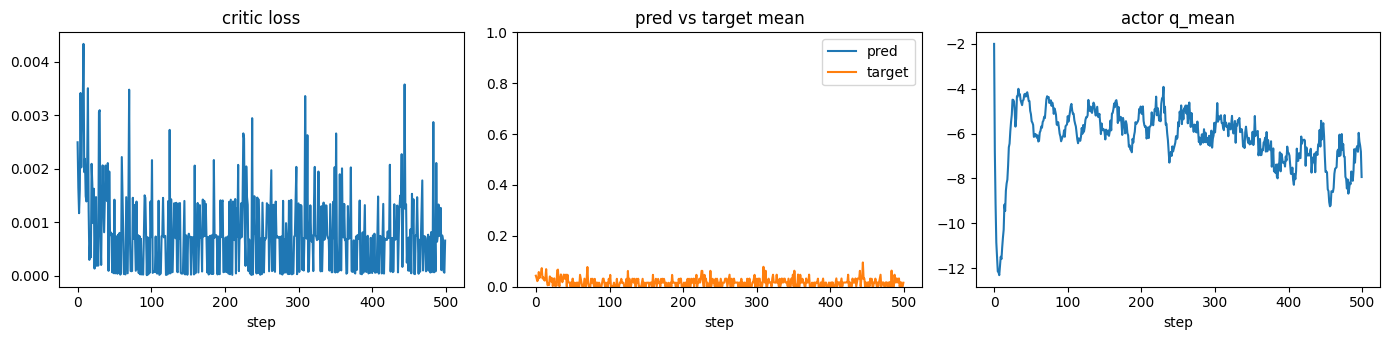

In [ ]:
# Quick plot of smoke-test losses (helpful if you want to spot trends visually)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(smoke_log['critic/critic_loss']); axes[0].set_title('critic loss'); axes[0].set_xlabel('step')
axes[1].plot(smoke_log['critic/pred_mean'], label='pred')
axes[1].plot(smoke_log['critic/target_mean'], label='target')
axes[1].set_title('pred vs target mean'); axes[1].legend(); axes[1].set_xlabel('step'); axes[1].set_ylim(0, 1)
axes[2].plot(smoke_log['actor/q_mean']); axes[2].set_title('actor q_mean'); axes[2].set_xlabel('step')
plt.tight_layout(); plt.show()

## 5. Full training run

1M gradient steps at batch 1024, evaluating every 100K steps. Checkpoints save to Drive every 100K steps — if Colab disconnects, you can resume by rerunning cells 1–3 in a new session and pointing at the latest checkpoint.

**Re-create the agent** below so we're not resuming the smoke-test state at full-size batch. (If you want to continue from the smoke test, skip the re-create cell.)

In [ ]:
# Re-create a fresh agent for the real run
random.seed(SEED); np.random.seed(SEED)
agent = agent_class.create(
    SEED,
    example_batch['observations'],
    example_batch['actions'],
    config,
)
print('Fresh agent created for full run.')

Fresh agent created for full run.


In [ ]:
DRIVE_ROOT = '/content/drive/MyDrive/cos435-final-project/test-runs'

In [ ]:
from utils.evaluation import evaluate
from utils.flax_utils import save_agent

TRAIN_STEPS = 1_000_000
LOG_INTERVAL = 5_000
EVAL_INTERVAL = 100_000
SAVE_INTERVAL = 100_000
EVAL_EPISODES = 20
EVAL_TEMPERATURE = 0.0

SAVE_DIR = f'{DRIVE_ROOT}/checkpoints_alpha10/{ENV_NAME}_seed{SEED}'
os.makedirs(SAVE_DIR, exist_ok=True)

train_history = defaultdict(list)  # keyed by metric name, list of (step, value)
eval_history = defaultdict(list)

# Task infos for evaluation
task_infos = env.unwrapped.task_infos if hasattr(env.unwrapped, 'task_infos') else env.task_infos
num_tasks = len(task_infos)
print(f'Training {ENV_NAME} for {TRAIN_STEPS:,} steps, {num_tasks} eval tasks')

Training pointmaze-large-navigate-v0 for 1,000,000 steps, 5 eval tasks


In [ ]:
from tqdm.auto import tqdm
import jax

BATCH = config['batch_size']
t0 = time.time()
last_log_t = time.time()

pbar = tqdm(range(1, TRAIN_STEPS + 1), smoothing=0.1, dynamic_ncols=True)
for step in pbar:
    batch = train_dataset_trl.sample(BATCH)
    agent, info = agent.update(batch)

    # Training metric logging
    if step % LOG_INTERVAL == 0:
        for k, v in info.items():
            train_history[k].append((step, float(v)))
        steps_per_sec = LOG_INTERVAL / (time.time() - last_log_t)
        last_log_t = time.time()
        pbar.set_postfix({
            'crit': f'{info["critic/critic_loss"]:.3f}',
            'pred': f'{info["critic/pred_mean"]:.3f}',
            'tgt': f'{info["critic/target_mean"]:.3f}',
            'sps': f'{steps_per_sec:.0f}',
        })

    # Evaluation
    if step == 1 or step % EVAL_INTERVAL == 0:
        eval_agent = agent  # no CPU offload; eval on GPU is fine for pointmaze
        overall_success = []
        for task_id in range(1, num_tasks + 1):
            task_name = task_infos[task_id - 1]['task_name']
            eval_info, _, _ = evaluate(
                agent=eval_agent, env=env, task_id=task_id, config=config,
                num_eval_episodes=EVAL_EPISODES, num_video_episodes=0,
                eval_temperature=EVAL_TEMPERATURE, eval_gaussian=None,
            )
            success = float(eval_info.get('success', 0.0))
            overall_success.append(success)
            eval_history[f'success/{task_name}'].append((step, success))
        mean_success = float(np.mean(overall_success))
        eval_history['success/overall'].append((step, mean_success))
        print(f'\n[eval @ step {step:,}] overall success: {mean_success:.3f} '
              f'(per-task: {[f"{s:.2f}" for s in overall_success]})')

    # Checkpoint
    if step % SAVE_INTERVAL == 0:
        save_agent(agent, SAVE_DIR, step)

pbar.close()
print(f'Done. Total wall time: {(time.time() - t0) / 60:.1f} min')

  0%|          | 0/1000000 [00:00<?, ?it/s]


100%|██████████| 20/20 [01:00<00:00,  3.02s/it]

100%|██████████| 20/20 [00:54<00:00,  2.72s/it]

100%|██████████| 20/20 [00:55<00:00,  2.79s/it]

100%|██████████| 20/20 [00:54<00:00,  2.73s/it]

100%|██████████| 20/20 [00:56<00:00,  2.80s/it]



[eval @ step 1] overall success: 0.000 (per-task: ['0.00', '0.00', '0.00', '0.00', '0.00'])



100%|██████████| 20/20 [00:21<00:00,  1.06s/it]

100%|██████████| 20/20 [00:54<00:00,  2.72s/it]

100%|██████████| 20/20 [00:46<00:00,  2.34s/it]

100%|██████████| 20/20 [00:54<00:00,  2.73s/it]

100%|██████████| 20/20 [00:54<00:00,  2.73s/it]



[eval @ step 100,000] overall success: 0.230 (per-task: ['0.95', '0.00', '0.20', '0.00', '0.00'])
Saved to /content/drive/MyDrive/cos435-final-project/test-runs/checkpoints_alpha10/pointmaze-large-navigate-v0_seed0/params_100000.pkl


...


[eval @ step 300,000] overall success: 0.200 (per-task: ['1.00', '0.00', '0.00', '0.00', '0.00'])
Saved to /content/drive/MyDrive/cos435-final-project/test-runs/checkpoints_alpha10/pointmaze-large-navigate-v0_seed0/params_300000.pkl



100%|██████████| 20/20 [00:12<00:00,  1.65it/s]

100%|██████████| 20/20 [00:53<00:00,  2.65s/it]

100%|██████████| 20/20 [00:53<00:00,  2.65s/it]

100%|██████████| 20/20 [00:53<00:00,  2.65s/it]

100%|██████████| 20/20 [00:53<00:00,  2.68s/it]



[eval @ step 400,000] overall success: 0.200 (per-task: ['1.00', '0.00', '0.00', '0.00', '0.00'])
Saved to /content/drive/MyDrive/cos435-final-project/test-runs/checkpoints_alpha10/pointmaze-large-navigate-v0_seed0/params_400000.pkl



100%|██████████| 20/20 [00:12<00:00,  1.64it/s]

100%|██████████| 20/20 [00:52<00:00,  2.65s/it]

100%|██████████| 20/20 [00:53<00:00,  2.68s/it]

100%|██████████| 20/20 [00:51<00:00,  2.57s/it]

100%|██████████| 20/20 [00:52<00:00,  2.62s/it]



[eval @ step 500,000] overall success: 0.200 (per-task: ['1.00', '0.00', '0.00', '0.00', '0.00'])
Saved to /content/drive/MyDrive/cos435-final-project/test-runs/checkpoints_alpha10/pointmaze-large-navigate-v0_seed0/params_500000.pkl


## 6. Plots & diagnostics

In [ ]:
def series(history, key):
    pts = history[key]
    if not pts:
        return np.array([]), np.array([])
    xs, ys = zip(*pts)
    return np.array(xs), np.array(ys)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Critic loss
x, y = series(train_history, 'critic/critic_loss')
axes[0, 0].plot(x, y)
axes[0, 0].set_title('Critic loss')
axes[0, 0].set_xlabel('step'); axes[0, 0].set_ylabel('loss')

# Actor loss
x, y = series(train_history, 'actor/actor_loss')
axes[0, 1].plot(x, y)
axes[0, 1].set_title('Actor loss')
axes[0, 1].set_xlabel('step')

# Pred vs target mean
x_p, y_p = series(train_history, 'critic/pred_mean')
x_t, y_t = series(train_history, 'critic/target_mean')
axes[1, 0].plot(x_p, y_p, label='pred_mean')
axes[1, 0].plot(x_t, y_t, label='target_mean')
axes[1, 0].set_title('Critic predictions vs targets')
axes[1, 0].set_xlabel('step'); axes[1, 0].set_ylim(0, 1); axes[1, 0].legend()

# Success rate over training
x, y = series(eval_history, 'success/overall')
axes[1, 1].plot(x, y, marker='o')
axes[1, 1].set_title('Overall success rate')
axes[1, 1].set_xlabel('step'); axes[1, 1].set_ylim(-0.05, 1.05)

plt.tight_layout(); plt.show()

In [ ]:
# Per-task success breakdown
per_task_keys = [k for k in eval_history if k.startswith('success/') and k != 'success/overall']
plt.figure(figsize=(6, 6))
for k in per_task_keys:
    x, y = series(eval_history, k)
    plt.plot(x, y, marker='.', label=k.replace('success/', ''))
plt.title('Per-task success')
plt.xlabel('step'); plt.ylabel('success'); plt.ylim(-0.05, 1.05); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Distribution of Q predictions on a fresh batch — sanity check on the learned value function.
# For pointmaze, we expect most Q values to be in (0, 1) with a reasonable spread.
import jax.numpy as jnp

batch = train_dataset_trl.sample(4096)
logits = agent.network.select('critic')(batch['s_i'], batch['s_j'], batch['a_i'])
if logits.ndim > 1:
    logits = jnp.min(logits, axis=0)
probs = jax.nn.sigmoid(logits)
distances = jnp.log(jnp.clip(probs, 1e-8, 1 - 1e-8)) / jnp.log(config['discount'])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(np.array(probs), bins=50)
axes[0].set_title('Q(s_i, a_i, s_j) distribution'); axes[0].set_xlabel('Q'); axes[0].set_xlim(0, 1)
axes[1].hist(np.array(distances), bins=50)
axes[1].set_title('Estimated distance log_gamma Q'); axes[1].set_xlabel('steps')
plt.tight_layout(); plt.show()

print(f'Q summary: min={float(probs.min()):.3f} median={float(jnp.median(probs)):.3f} max={float(probs.max()):.3f}')

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/cos435-final-project/test-runs/checkpoints_alpha10/pointmaze-large-navigate-v0_seed0'
DRIVE_ROOT = '/content/drive/MyDrive/cos435-final-project/test-runs'

In [ ]:
from utils.flax_utils import restore_agent
agent = restore_agent(agent, SAVE_DIR, restore_epoch=1000000)

In [ ]:
# Render one evaluation rollout per task as a video for visual inspection.
import imageio

video_dir = f'{DRIVE_ROOT}/videos_{ENV_NAME}_seed{SEED}'
os.makedirs(video_dir, exist_ok=True)

for task_id in range(1, num_tasks + 1):
    task_name = task_infos[task_id - 1]['task_name']
    _, _, renders = evaluate(
        agent=agent, env=env, task_id=task_id, config=config,
        num_eval_episodes=0, num_video_episodes=1, video_frame_skip=3,
        eval_temperature=EVAL_TEMPERATURE, eval_gaussian=None,
    )
    if renders:
        out_path = f'{video_dir}/task{task_id}_{task_name}.mp4'
        imageio.mimsave(out_path, renders[0], fps=15)
        print(f'Saved: {out_path}')
print('Open the video_dir path from Drive to view.')

## Troubleshooting notes

- **Critic loss flat or exploding**: check `pred_mean` — if it's stuck at 0.5 forever, the sigmoid isn't getting gradient signal, meaning the loss is decoupled from the critic. Usually a shape bug in `expectile_loss` or `transitive_target`.
- **`pred_mean` drifts to 0 or 1**: critic is saturating. Often means the expectile $\kappa$ is too aggressive for your batch distribution, or the base-case substitutions (`leg1_len <= 1`) aren't firing. Print `leg1_len` and `leg2_len` histograms from a batch.
- **Success rate stays at 0 past 200K steps**: the value function might be fine but the actor can't extract from it. Check `actor/q_mean` — if it's not increasing over training, the policy isn't finding high-$Q$ actions. Could be a reparameterization issue or BC coefficient `alpha` is too high.
- **Colab disconnects mid-run**: re-run cells 1–3 in a new session, then restore:
  ```python
  from utils.flax_utils import restore_agent
  agent = restore_agent(agent, SAVE_DIR, restore_epoch=<latest step>)
  ```
  and continue the training loop from that step. (You'll need to pass `start=<latest step>` when resuming, not shown in the loop above — easy edit.)
- **OOM on the full run**: reduce `batch_size` in `config` to 512 or 256. Pointmaze is small; this shouldn't happen on T4 but can on older GPUs.

**Expected outcome for `pointmaze-large-navigate-v0`**: per Table 2 of the paper, TRL reaches around 33% overall success on the `oraclerep` variant. The non-oraclerep variant (what you're running) has the full state as the goal, which is a slightly easier learning problem, so expect ~30-50% overall depending on the task mix. The main goal of this first run is to confirm the pipeline is alive — not to hit headline numbers.